#### Task 1.2: EDA & Statistical Analysis - Car Insurance Data

**Project:** AlphaCare Insurance Solutions – Risk & Profitability Analytics  
**Objective:** Understand client, location, and vehicle-based patterns in insurance data to help optimize marketing strategies and risk management.

---

##### 1. Introduction

This notebook performs exploratory data analysis (EDA) on historical car insurance claim data from Feb 2014 to Aug 2015 to:

- Understand data structure and quality
- Identify trends and outliers in key metrics like TotalPremium, TotalClaims
- Measure **Loss Ratio** and how it varies by Province, Gender, VehicleType
- Analyze spatial and temporal trends in risk and profitability

---

##### Import libs and setup

In [3]:
# Import libs & setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("Step 1: Libraries imported successfully.\n")


Step 1: Libraries imported successfully.



#### 2. Data Loading & Structure Check

In [7]:
try:
    file_path = '../data/raw/MachineLearningRating_v3.txt'
    df = pd.read_csv(file_path, delimiter='|')
    print(f"Step 2: Data loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.\n")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}. Please check the file path and try again.\n")
except Exception as e:
    print(f"Unexpected error loading data: {e}\n")
    
# Peek at data if loaded
if 'df' in globals():
    display(df.head())


Step 2: Data loaded successfully with 1000098 rows and 52 columns.



,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


#### 3. Data Quality Assessment

In [8]:
try:
    missing = df.isnull().sum()
    missing_vals = missing[missing > 0]
    print("Step 3: Missing values by column:")
    if missing_vals.empty:
        print("No missing values detected.\n")
    else:
        print(missing_vals, "\n")
except Exception as e:
    print(f"Error during missing values check: {e}\n")

try:
    duplicates = df.duplicated().sum()
    print(f"Duplicated rows count: {duplicates}\n")
except Exception as e:
    print(f"Error during duplicate check: {e}\n")


Step 3: Missing values by column:
Bank                        145961
AccountType                  40232
MaritalStatus                 8259
Gender                        9536
mmcode                         552
VehicleType                    552
make                           552
Model                          552
Cylinders                      552
cubiccapacity                  552
kilowatts                      552
bodytype                       552
NumberOfDoors                  552
VehicleIntroDate               552
CustomValueEstimate         779642
CapitalOutstanding               2
NewVehicle                  153295
WrittenOff                  641901
Rebuilt                     641901
Converted                   641901
CrossBorder                 999400
NumberOfVehiclesInFleet    1000098
dtype: int64 

Duplicated rows count: 0



#### 4. Descriptive Statistics

In [9]:
try:
    desc_stats = df[['TotalPremium', 'TotalClaims', 'CustomValueEstimate']].describe()
    print("Step 4: Descriptive statistics for key numeric columns:\n")
    display(desc_stats)
except Exception as e:
    print(f"Error calculating descriptive statistics: {e}\n")

try:
    variability = df[['TotalPremium', 'TotalClaims', 'CustomValueEstimate']].std()
    print("Variability (std deviation) for key numeric columns:\n", variability, "\n")
except Exception as e:
    print(f"Error calculating variability: {e}\n")


Step 4: Descriptive statistics for key numeric columns:



,TotalPremium,TotalClaims,CustomValueEstimate
count,1.000098e+06,1.000098e+06,2.204560e+05
mean,6.190550e+01,6.486119e+01,2.255311e+05
std,2.302845e+02,2.384075e+03,5.645157e+05
min,-7.825768e+02,-1.200241e+04,2.000000e+04
25%,0.000000e+00,0.000000e+00,1.350000e+05
50%,2.178333e+00,0.000000e+00,2.200000e+05
75%,2.192982e+01,0.000000e+00,2.800000e+05
max,6.528260e+04,3.930921e+05,2.655000e+07


Variability (std deviation) for key numeric columns:
 TotalPremium              230.284513
TotalClaims              2384.074695
CustomValueEstimate    564515.749848
dtype: float64 



#### 5. Univariate Analysis

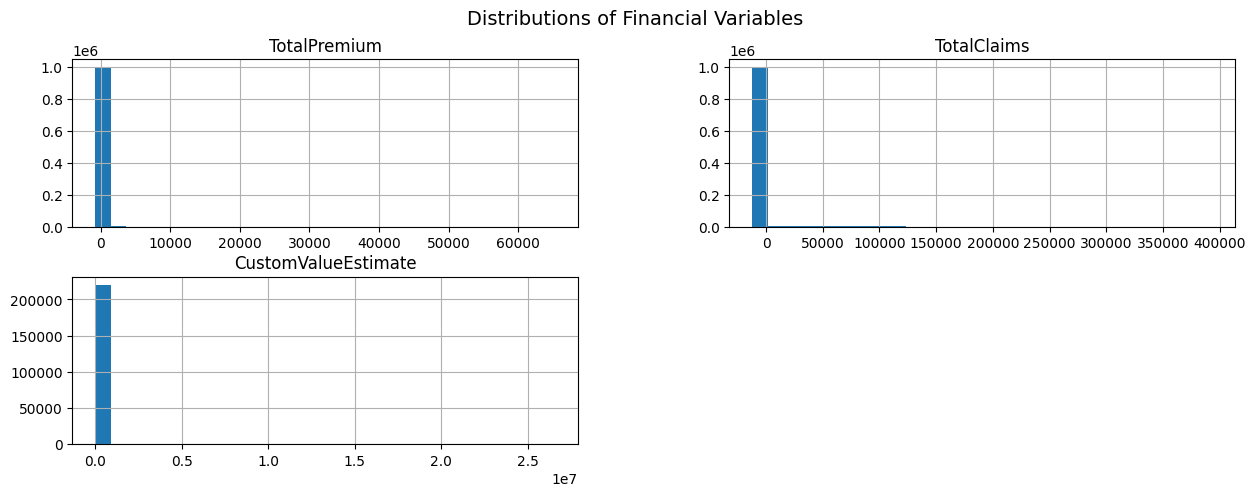

Step 5: Numerical distributions plotted.



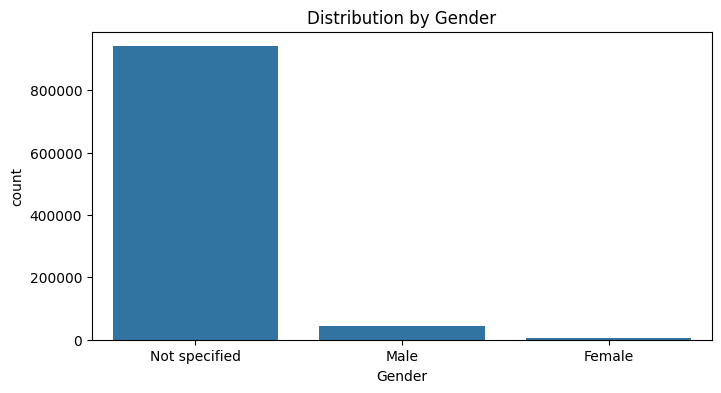

Step 5: Categorical distribution by Gender plotted.



In [10]:
try:
    num_cols = ['TotalPremium', 'TotalClaims', 'CustomValueEstimate']
    df[num_cols].hist(bins=30, figsize=(15, 5))
    plt.suptitle("Distributions of Financial Variables", fontsize=14)
    plt.show()
    print("Step 5: Numerical distributions plotted.\n")
except Exception as e:
    print(f"Error plotting numerical distributions: {e}\n")

try:
    plt.figure(figsize=(8,4))
    sns.countplot(x='Gender', data=df)
    plt.title("Distribution by Gender")
    plt.show()
    print("Step 5: Categorical distribution by Gender plotted.\n")
except Exception as e:
    print(f"Error plotting gender distribution: {e}\n")


#### 6. Bivariate / Multivariate Analysis

Step 6: LossRatio calculated and cleaned.



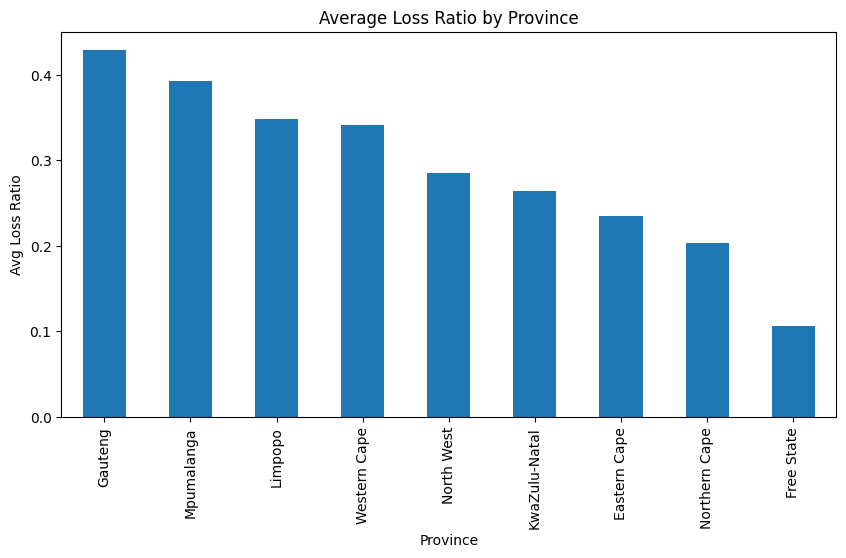

Step 6: Loss Ratio by Province plotted.



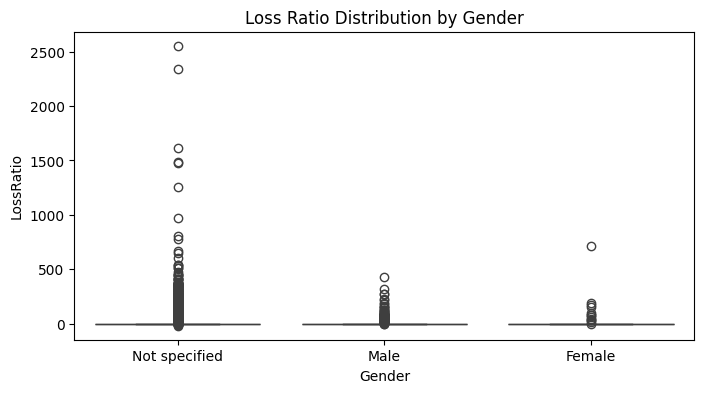

Step 6: Loss Ratio by Gender plotted.



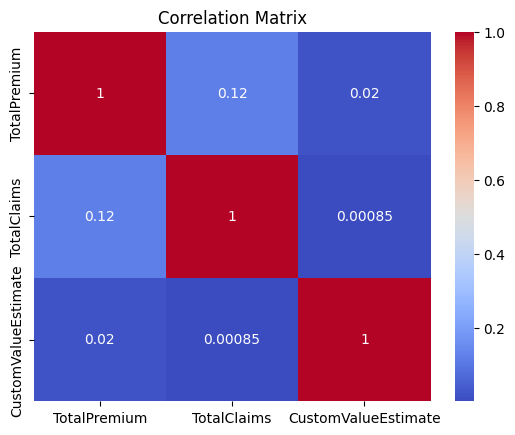

Step 6: Correlation matrix plotted.



In [11]:
try:
    df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
    df['LossRatio'].replace([np.inf, -np.inf], np.nan, inplace=True)
    print("Step 6: LossRatio calculated and cleaned.\n")
except Exception as e:
    print(f"Error calculating LossRatio: {e}\n")

try:
    loss_by_province = df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False)
    loss_by_province.plot(kind='bar', figsize=(10,5), title='Average Loss Ratio by Province')
    plt.ylabel('Avg Loss Ratio')
    plt.show()
    print("Step 6: Loss Ratio by Province plotted.\n")
except Exception as e:
    print(f"Error plotting Loss Ratio by Province: {e}\n")

try:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='Gender', y='LossRatio', data=df)
    plt.title('Loss Ratio Distribution by Gender')
    plt.show()
    print("Step 6: Loss Ratio by Gender plotted.\n")
except Exception as e:
    print(f"Error plotting Loss Ratio by Gender: {e}\n")

try:
    corr = df[['TotalPremium', 'TotalClaims', 'CustomValueEstimate']].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title("Correlation Matrix")
    plt.show()
    print("Step 6: Correlation matrix plotted.\n")
except Exception as e:
    print(f"Error plotting correlation matrix: {e}\n")


#### 7. Geographical & Temporal Trends

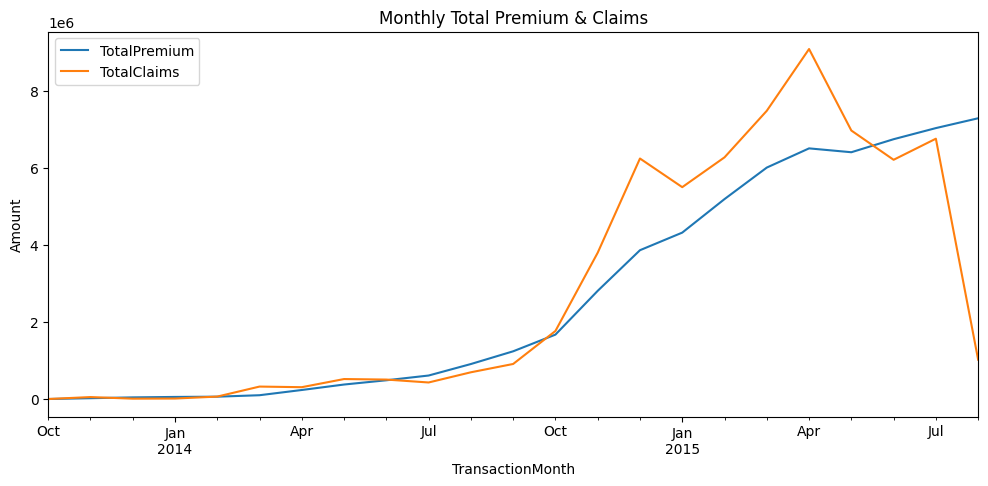

Step 7: Temporal trends plotted.



In [16]:
try:
    df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')
    monthly = df.groupby(df['TransactionMonth'].dt.to_period('M'))[['TotalPremium', 'TotalClaims']].sum()
    monthly.plot(figsize=(12,5), title='Monthly Total Premium & Claims')
    plt.ylabel('Amount')
    plt.show()
    print("Step 7: Temporal trends plotted.\n")
except Exception as e:
    print(f"Error plotting temporal trends: {e}\n")



#### 8. Outlier Detection

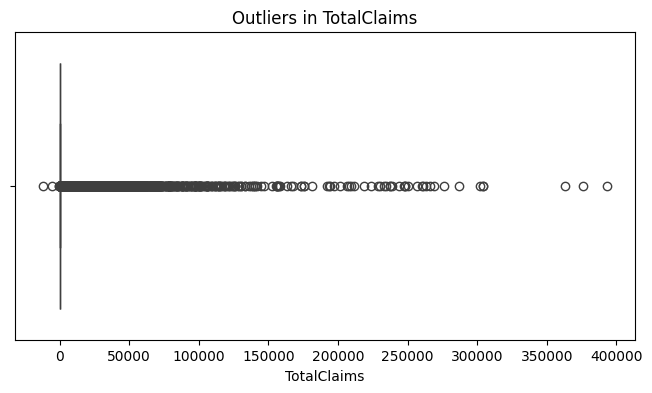

Step 8: Outliers in TotalClaims detected.



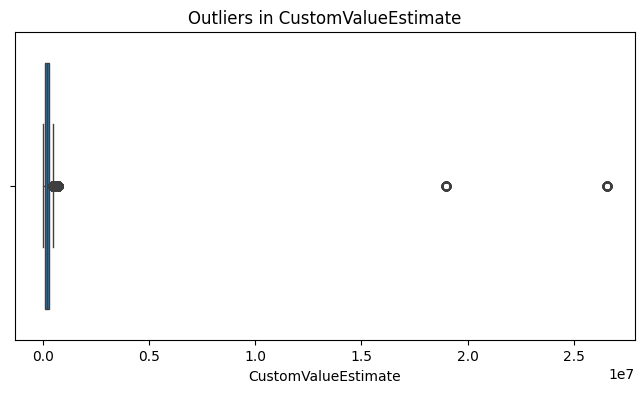

Step 8: Outliers in CustomValueEstimate detected.



In [13]:
try:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df['TotalClaims'])
    plt.title('Outliers in TotalClaims')
    plt.show()
    print("Step 8: Outliers in TotalClaims detected.\n")
except Exception as e:
    print(f"Error detecting outliers in TotalClaims: {e}\n")

try:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df['CustomValueEstimate'])
    plt.title('Outliers in CustomValueEstimate')
    plt.show()
    print("Step 8: Outliers in CustomValueEstimate detected.\n")
except Exception as e:
    print(f"Error detecting outliers in CustomValueEstimate: {e}\n")


#### 9. Creative Visualizations

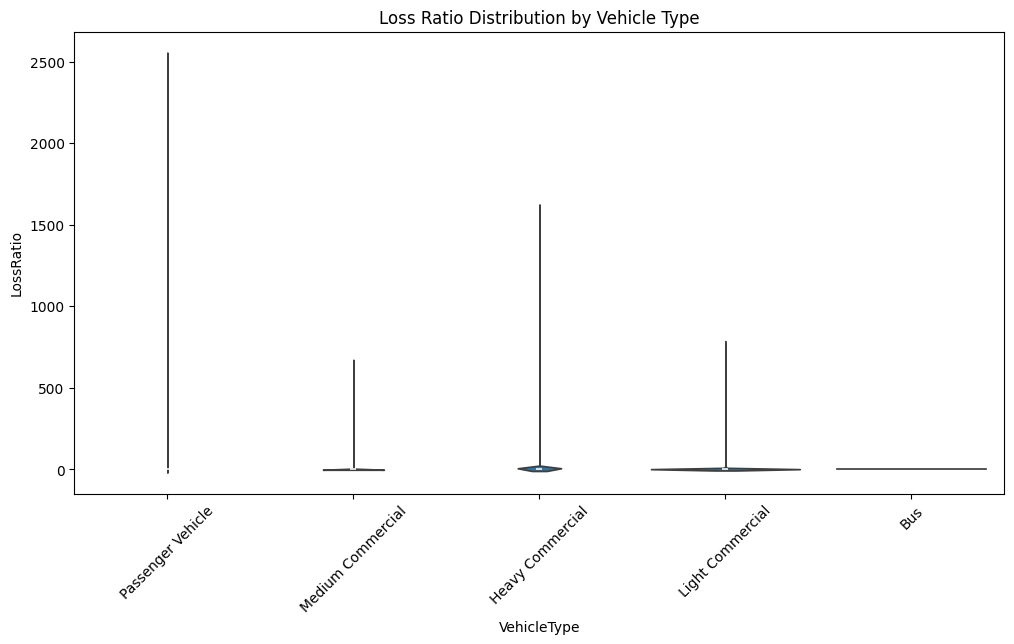

Step 9: Violin plot created.



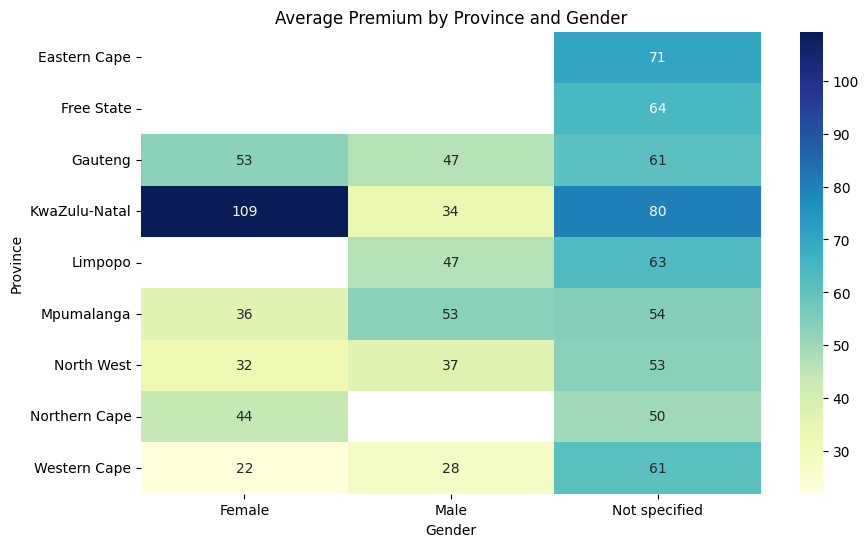

Step 9: Heatmap created.



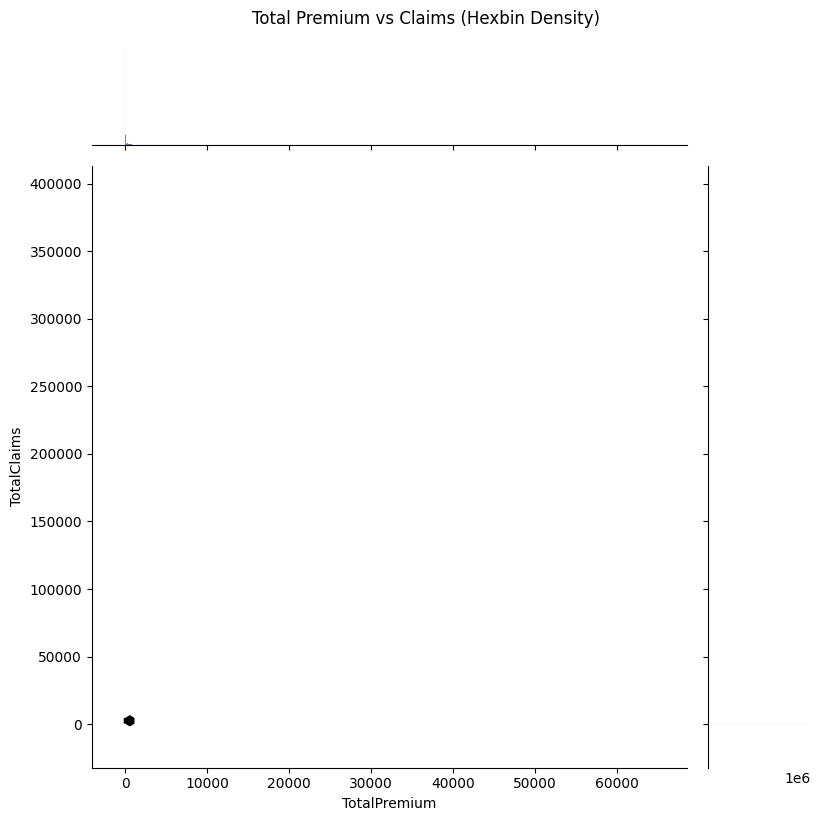

Step 9: Jointplot created.



In [14]:
try:
    plt.figure(figsize=(12,6))
    sns.violinplot(x='VehicleType', y='LossRatio', data=df)
    plt.xticks(rotation=45)
    plt.title("Loss Ratio Distribution by Vehicle Type")
    plt.show()
    print("Step 9: Violin plot created.\n")
except Exception as e:
    print(f"Error creating violin plot: {e}\n")

try:
    heat_df = df.pivot_table(index='Province', columns='Gender', values='TotalPremium', aggfunc='mean')
    plt.figure(figsize=(10,6))
    sns.heatmap(heat_df, annot=True, fmt=".0f", cmap='YlGnBu')
    plt.title("Average Premium by Province and Gender")
    plt.show()
    print("Step 9: Heatmap created.\n")
except Exception as e:
    print(f"Error creating heatmap: {e}\n")

try:
    sns.jointplot(x='TotalPremium', y='TotalClaims', data=df, kind='hex', height=8)
    plt.suptitle("Total Premium vs Claims (Hexbin Density)", y=1.02)
    plt.show()
    print("Step 9: Jointplot created.\n")
except Exception as e:
    print(f"Error creating jointplot: {e}\n")
